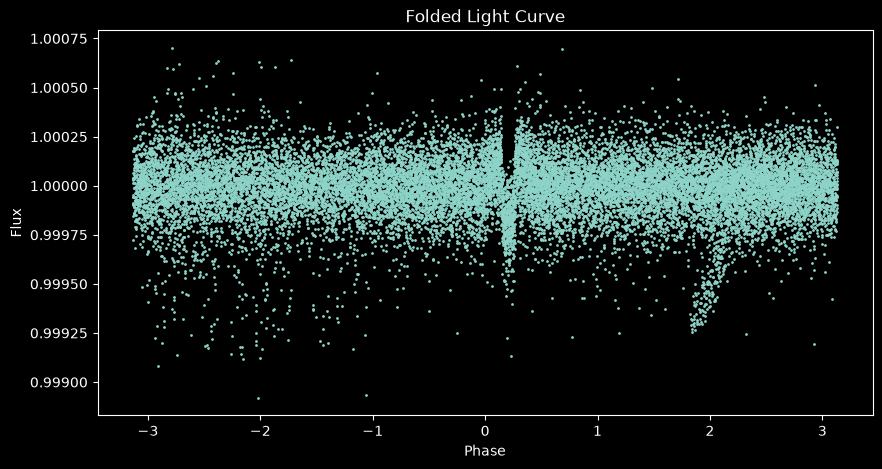

In [9]:
import matplotlib.pyplot as plt
from lightkurve import TessTargetPixelFile
from astropy.timeseries import BoxLeastSquares

FILE = "exofind/data/target_pixel/tess2018206045859-s0001-0000000261136679-0120-s_tp.fits"

tpf = TessTargetPixelFile(FILE)

# Standard Lightkurve aperture photometry
lc = tpf.to_lightcurve(aperture_mask="pipeline")

# Remove bad cadences
lc = lc.remove_nans().remove_outliers()

# Flatten
flat = lc.flatten(window_length=401)

time = flat.time.value
flux = flat.flux.value

bls = BoxLeastSquares(time, flux)

periods = bls.autoperiod(duration=0.1)

result = bls.power(
    periods,
    0.1
)

best = result.power.argmax()


plt.figure(figsize=(12,5))
plt.plot(result.period, result.power)
plt.xlabel("Period (days)")
plt.ylabel("BLS Power")
plt.title("Lightkurve BLS")
plt.show()

folded = flat.fold(period=result.period[best])

plt.figure(figsize=(10,5))
plt.plot(
    folded.phase.value,
    folded.flux.value,
    ".",
    markersize=2
)

plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Folded Light Curve")
plt.show()

In [10]:

print("=" * 40)
print("Lightkurve Validation")
print("=" * 40)

print("Best Period :", result.period[best])
print("Depth       :", result.depth[best])
print("Duration    :", result.duration[best])
print("Transit Time:", result.transit_time[best])

Lightkurve Validation
Best Period : 6.26848054850942
Depth       : 0.00017488116149462303
Duration    : 0.1
Transit Time: 1325.4969604950604
